# 03 - D Module Figures and Interpretation

This notebook presents D-module as the project's diagnostic and interpretation layer.

The central question is not whether D can make tables and plots. It can. The real question is what those outputs imply about the current state of the model.

That is the purpose of this notebook: to turn the raw CSV and PNG outputs into a defensible project-level reading.


## Key takeaways before reading the outputs

The current D-module outputs support two simultaneous conclusions.

Positive conclusion:
- The project already has a functioning evaluation layer with risk metrics, distribution comparison, and what-if attribution.

Critical conclusion:
- The current trained generator is still materially miscalibrated relative to the real test distribution.

This dual conclusion is exactly what a good D-module should produce. It should not merely generate attractive figures; it should tell us whether the model is believable.


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if Path('data').exists() and Path('outputs').exists():
    PROJECT_ROOT = Path.cwd()
elif Path.cwd().name == 'notebooks' and Path('../data').exists() and Path('../outputs').exists():
    PROJECT_ROOT = Path.cwd().parent
else:
    raise FileNotFoundError('Cannot locate project root from current notebook working directory.')

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)


In [9]:
TABLE_DIR = PROJECT_ROOT / 'outputs/tables'
FIG_DIR = PROJECT_ROOT / 'outputs/figures'

real_path = TABLE_DIR / 'd_real_risk_metrics.csv'
gen_path = TABLE_DIR / 'd_generated_risk_metrics.csv'
cmp_path = TABLE_DIR / 'd_distribution_compare.csv'
attr_path = TABLE_DIR / 'd_factor_sensitivity.csv'
meta_path = TABLE_DIR / 'd_factor_sensitivity_meta.json'

for p in [real_path, gen_path, cmp_path, attr_path, meta_path]:
    assert p.exists(), f'Missing file: {p}'

real_df = pd.read_csv(real_path)
gen_df = pd.read_csv(gen_path)
cmp_df = pd.read_csv(cmp_path)
attr_df = pd.read_csv(attr_path)

display(real_df)
display(gen_df.head())


,horizon,baseline_scope,alpha,count,mean,std,var_alpha,es_alpha,var_5pct,es_5pct,worst
0,last_day,overall_test,0.05,539,0.000848,0.018310,-0.022968,-0.037319,-0.022968,-0.037319,-0.10832
1,cum_20d,overall_test,0.05,539,0.018145,0.082648,-0.082947,-0.108719,-0.082947,-0.108719,-0.16119


,condition,checkpoint,horizon,alpha,count,mean,std,var_alpha,es_alpha,var_5pct,es_5pct,worst,source_file
0,cumret_5d,latest,last_day,0.05,1000,-4.614821,17.251662,-32.216623,-40.030638,-32.216623,-40.030638,-53.229572,outputs\samples\sample_cumret_5d_latest.npy
1,cumret_5d,latest,cum_20d,0.05,1000,-3.046903,42.438528,-74.427826,-99.934313,-74.427826,-99.934313,-216.015915,outputs\samples\sample_cumret_5d_latest.npy
2,high_risk_market,latest,last_day,0.05,1000,-4.432497,16.182614,-30.762710,-37.931774,-30.762710,-37.931774,-68.823700,outputs\samples\sample_high_risk_market_latest...
3,high_risk_market,latest,cum_20d,0.05,1000,-3.215568,42.135471,-73.469371,-94.744122,-73.469371,-94.744122,-135.109146,outputs\samples\sample_high_risk_market_latest...
4,normal_market,latest,last_day,0.05,1000,-4.502521,17.051161,-32.239563,-39.302160,-32.239563,-39.302160,-51.185467,outputs\samples\sample_normal_market_latest.npy


## 1) Real versus generated risk magnitude

This is the most important table in the notebook because it immediately reveals whether the generated scenarios live on the same numerical scale as the real test data.

How to read it:
- Start from the real-data rows. They define the baseline scale of plausible daily and 20-day risk in the current dataset.
- Then compare generated `mean`, `var_alpha`, and `es_alpha` against that baseline.

What the current result shows:
- Real last-day ES is modestly negative, as one would expect from a real ETF basket.
- Generated last-day and cumulative means are much more negative than the real baseline.
- Generated left tails are also dramatically more extreme.

Interpretation:
- The current generator is not yet producing realistic market-scale scenarios.
- At this stage, the generated samples behave more like over-amplified stress paths than calibrated synthetic market paths.

This is a substantive model-quality conclusion, not merely a descriptive statistic.


In [10]:
cols = ['condition', 'checkpoint', 'horizon', 'alpha', 'mean', 'var_alpha', 'es_alpha', 'worst']
gen_short = gen_df[cols].copy().sort_values(['horizon', 'condition', 'checkpoint'])
display(real_df)
display(gen_short)


,horizon,baseline_scope,alpha,count,mean,std,var_alpha,es_alpha,var_5pct,es_5pct,worst
0,last_day,overall_test,0.05,539,0.000848,0.018310,-0.022968,-0.037319,-0.022968,-0.037319,-0.10832
1,cum_20d,overall_test,0.05,539,0.018145,0.082648,-0.082947,-0.108719,-0.082947,-0.108719,-0.16119


,condition,checkpoint,horizon,alpha,mean,var_alpha,es_alpha,worst
1,cumret_5d,latest,cum_20d,0.05,-3.046903,-74.427826,-99.934313,-216.015915
3,high_risk_market,latest,cum_20d,0.05,-3.215568,-73.469371,-94.744122,-135.109146
5,normal_market,latest,cum_20d,0.05,-0.433048,-69.790154,-96.736471,-187.847244
7,vol_20d,latest,cum_20d,0.05,-1.847288,-71.760101,-97.266461,-167.856613
0,cumret_5d,latest,last_day,0.05,-4.614821,-32.216623,-40.030638,-53.229572
2,high_risk_market,latest,last_day,0.05,-4.432497,-30.762710,-37.931774,-68.823700
4,normal_market,latest,last_day,0.05,-4.502521,-32.239563,-39.302160,-51.185467
6,vol_20d,latest,last_day,0.05,-4.568314,-32.712483,-39.626184,-55.832512


## 2) Distribution mismatch diagnostics

Risk metrics alone can miss shape differences. This is why the notebook also reviews KS, histogram rank correlation, and Wasserstein distance.

Why these diagnostics matter:
- `ks_stat` measures global distribution mismatch.
- `ks_pvalue` indicates whether the mismatch is statistically negligible or clearly real.
- `wasserstein_distance` gives a transport-style notion of how far the distributions are apart in scale.
- `spearman_hist` is weaker but still useful as a coarse shape-similarity signal.

What the current outputs imply:
- KS values around `0.5` to `0.6` are large.
- P-values are effectively zero.
- Wasserstein distances are large on both horizons.

So the model is not just slightly off in the tail. The overall generated distribution family is still far from the real one.


In [11]:
cmp_short = cmp_df[['condition', 'checkpoint', 'horizon', 'ks_stat', 'ks_pvalue', 'spearman_hist', 'wasserstein_distance']].copy()
cmp_short.sort_values(['horizon', 'condition', 'checkpoint'])


,condition,checkpoint,horizon,ks_stat,ks_pvalue,spearman_hist,wasserstein_distance
1,cumret_5d,latest,cum_20d,0.509,2.532305e-83,0.228928,32.473812
3,high_risk_market,latest,cum_20d,0.500,2.846964e-80,0.242928,33.016646
5,normal_market,latest,cum_20d,0.525,6.510521e-89,0.215044,30.833110
7,vol_20d,latest,cum_20d,0.503,2.784975e-81,0.215094,31.312244
0,cumret_5d,latest,last_day,0.599,1.103665e-117,0.131795,14.083554
2,high_risk_market,latest,last_day,0.612,2.891163e-123,0.279533,13.093751
4,normal_market,latest,last_day,0.620,8.756934e-127,0.166486,14.093592
6,vol_20d,latest,last_day,0.628,2.281819e-130,0.229047,13.630801


## 3) Condition comparison plots

The next question is whether the conditional interface is doing anything meaningful at all.

What these plots help answer:
- Do different conditions produce different risk outcomes?
- Even if the model is miscalibrated overall, is the conditioning channel at least active?

How to interpret the current figures:
- If the bars differ by condition, then the model is responding to conditional inputs.
- If they all collapse to the same level, the conditional mechanism is effectively ignored.

In the current project state, the model does show condition-dependent variation. That is encouraging. The problem is that this variation still sits on top of a badly shifted distribution.


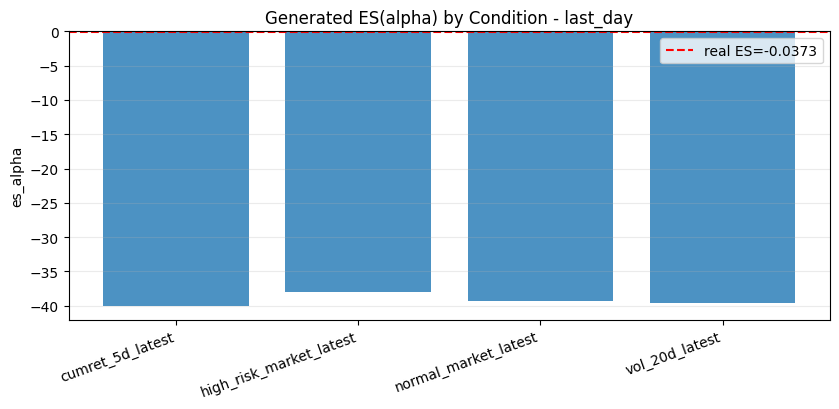

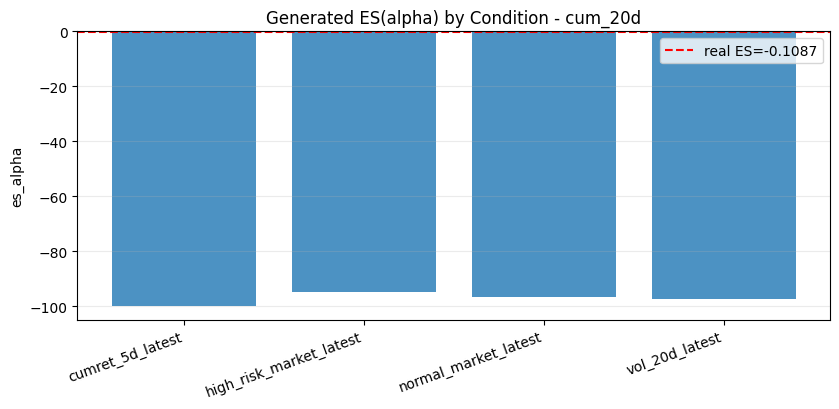

In [12]:
def es_bar_from_table(real_df: pd.DataFrame, gen_df: pd.DataFrame, horizon: str) -> None:
    real_es = float(real_df.loc[real_df['horizon'] == horizon, 'es_alpha'].iloc[0])
    sub = gen_df[gen_df['horizon'] == horizon].copy().sort_values(['condition', 'checkpoint'])
    labels = (sub['condition'] + '_' + sub['checkpoint']).tolist()
    values = sub['es_alpha'].astype(float).to_numpy()

    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    ax.bar(np.arange(len(labels)), values, alpha=0.8)
    ax.axhline(real_es, color='red', linestyle='--', linewidth=1.5, label=f'real ES={real_es:.4f}')
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_title(f'Generated ES(alpha) by Condition - {horizon}')
    ax.set_ylabel('es_alpha')
    ax.grid(axis='y', alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


es_bar_from_table(real_df, gen_df, 'last_day')
es_bar_from_table(real_df, gen_df, 'cum_20d')


## 4) What the attribution module is really telling us

Attribution is easy to oversell, so this section needs careful wording.

What the current attribution module is:
- A condition-level what-if sensitivity analysis.
- It perturbs one condition factor while holding a base condition template fixed.
- It then measures how risk outputs move.

What it is not:
- It is not a pathwise reverse-diffusion attribution method.
- It is not yet a causal explanation of why a particular generated path occurred.

How to interpret the current results:
- ES changes across factor values, so the model does react to conditions.
- That means the conditional channel is not dead.
- But because the generator is globally miscalibrated, these attribution curves should currently be read as qualitative sensitivity evidence, not final financial conclusions.


,checkpoint,base_condition,factor,factor_value,horizon,alpha,count,mean,std,var_alpha,es_alpha,var_5pct,es_5pct,worst,delta_var_5pct,delta_es_5pct
0,latest,normal_market,baseline,0.0,last_day,0.05,256,-3.040448,15.899318,-30.075406,-34.540148,-30.075406,-34.540148,-46.163208,0.000000,0.000000
1,latest,normal_market,baseline,0.0,cum_20d,0.05,256,1.143257,43.335267,-77.030922,-103.134785,-77.030922,-103.134785,-159.097931,0.000000,0.000000
2,latest,normal_market,cumret_5d,-1.0,last_day,0.05,256,-3.026765,17.177451,-29.475441,-35.607597,-29.475441,-35.607597,-46.615009,0.599965,-1.067448
3,latest,normal_market,cumret_5d,-1.0,cum_20d,0.05,256,0.305206,41.127586,-64.506197,-87.262343,-64.506197,-87.262343,-120.969810,12.524725,15.872442
4,latest,normal_market,cumret_5d,-0.5,last_day,0.05,256,-2.320556,16.793228,-30.546095,-36.303108,-30.546095,-36.303108,-46.248028,-0.470689,-1.762959
5,latest,normal_market,cumret_5d,-0.5,cum_20d,0.05,256,-5.379740,42.026826,-76.351175,-106.124438,-76.351175,-106.124438,-143.946121,0.679747,-2.989653
6,latest,normal_market,cumret_5d,0.0,last_day,0.05,256,-4.243962,16.896970,-31.550076,-38.738376,-31.550076,-38.738376,-57.061012,-1.474670,-4.198228
7,latest,normal_market,cumret_5d,0.0,cum_20d,0.05,256,-3.343424,42.388786,-80.183905,-103.472885,-80.183905,-103.472885,-140.979919,-3.152983,-0.338100
8,latest,normal_market,cumret_5d,0.5,last_day,0.05,256,-1.792759,17.707949,-27.490154,-38.627964,-27.490154,-38.627964,-59.898277,2.585252,-4.087816
9,latest,normal_market,cumret_5d,0.5,cum_20d,0.05,256,1.650795,38.499997,-58.367758,-82.712940,-58.367758,-82.712940,-142.436401,18.663164,20.421845


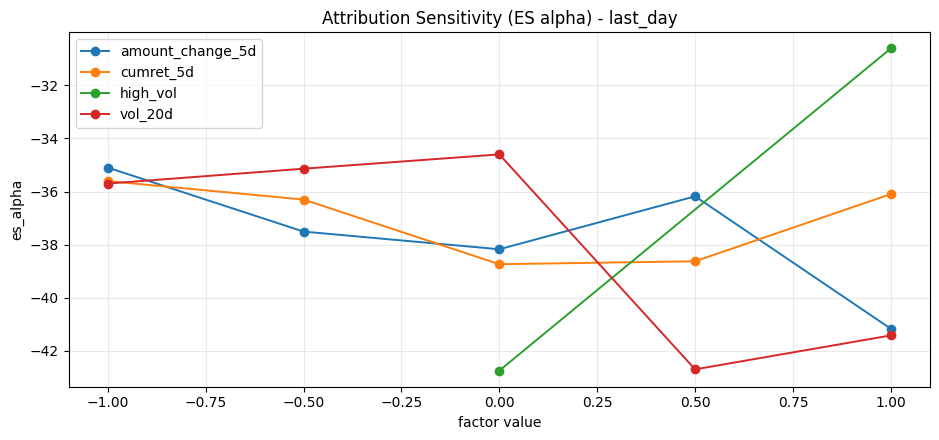

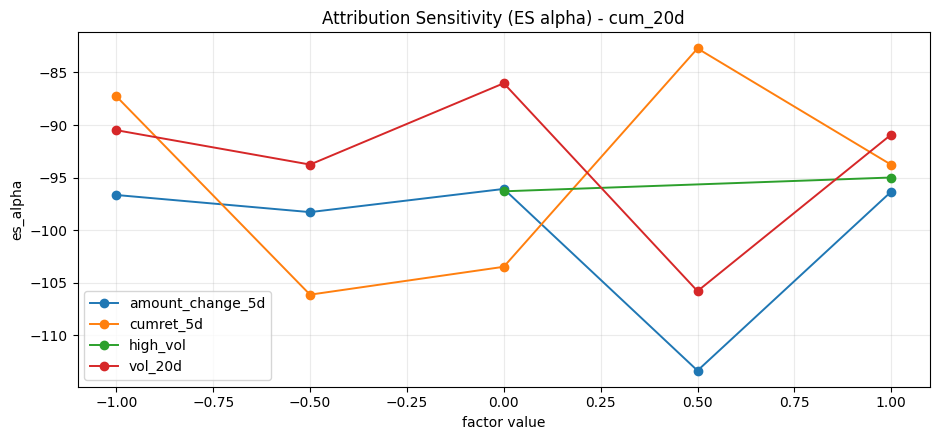

In [13]:
sub = attr_df[attr_df['factor'] != 'baseline'].copy()
sub['factor_value'] = sub['factor_value'].astype(float)

display(attr_df.head(12))

for hz in ['last_day', 'cum_20d']:
    hz_df = sub[sub['horizon'] == hz]
    fig, ax = plt.subplots(figsize=(9.5, 4.5))
    for factor, g in hz_df.groupby('factor'):
        g = g.sort_values('factor_value')
        ax.plot(g['factor_value'], g['es_alpha'], marker='o', linewidth=1.4, label=factor)
    ax.set_title(f'Attribution Sensitivity (ES alpha) - {hz}')
    ax.set_xlabel('factor value')
    ax.set_ylabel('es_alpha')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


## 5) Reading the exported figures in context

The saved PNG files are best used after the tabular interpretation above.

Why:
- Without the table reading, the plots may look visually impressive but analytically ambiguous.
- After the table reading, the figures become evidence for a precise conclusion: the pipeline is complete, the evaluation is functioning, and the model still needs calibration work.

That is the correct narrative for the current state of the project.


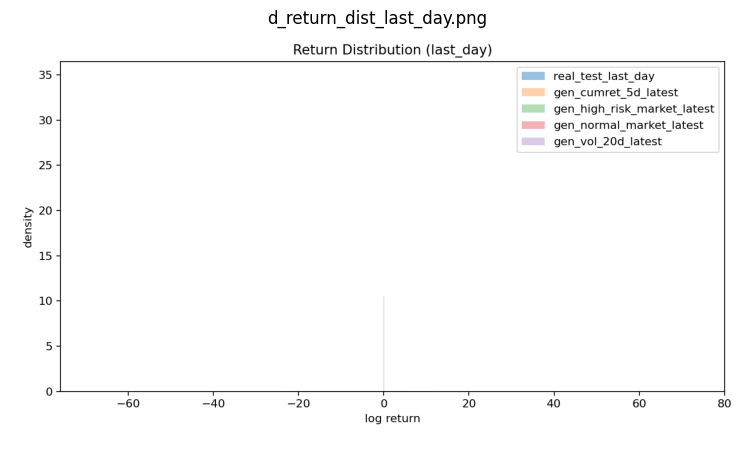

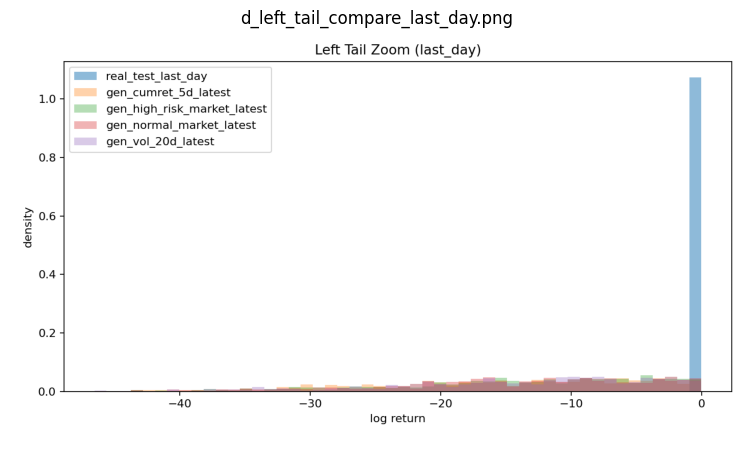

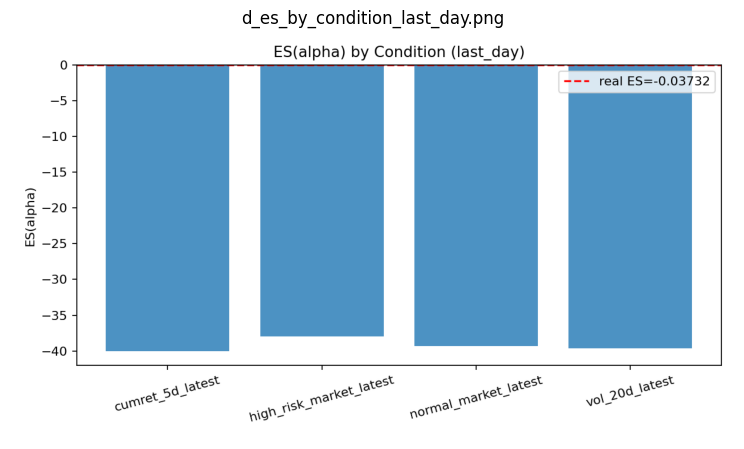

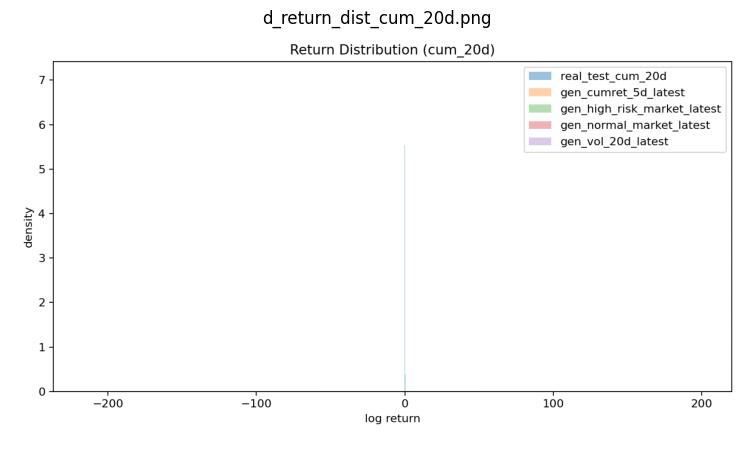

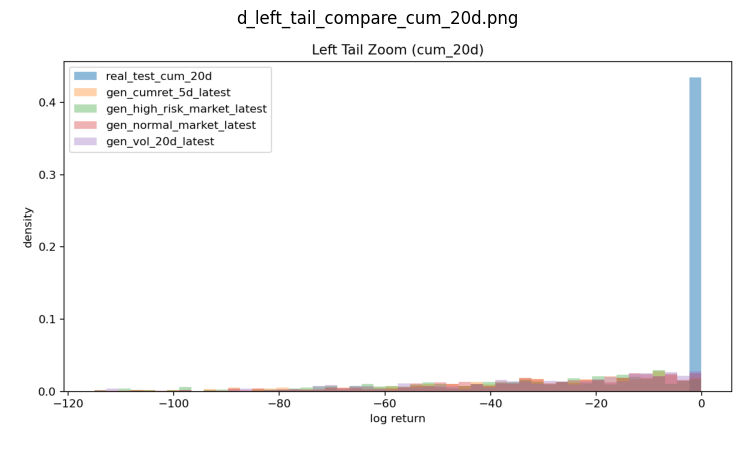

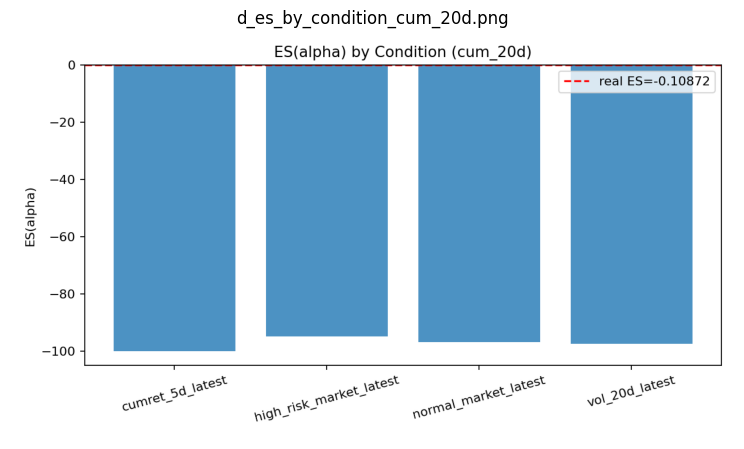

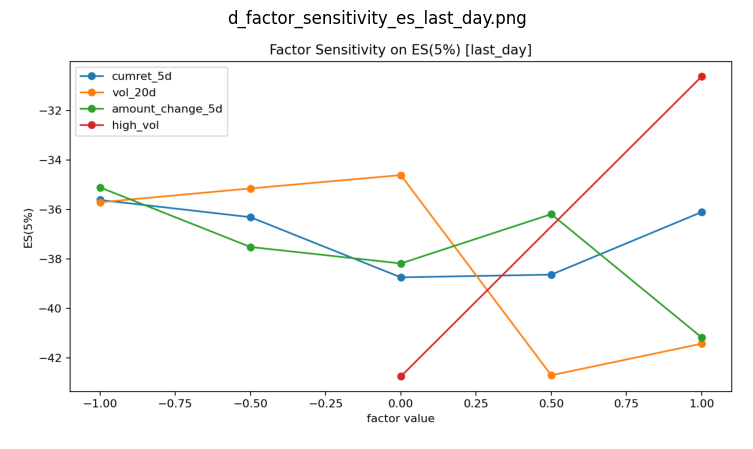

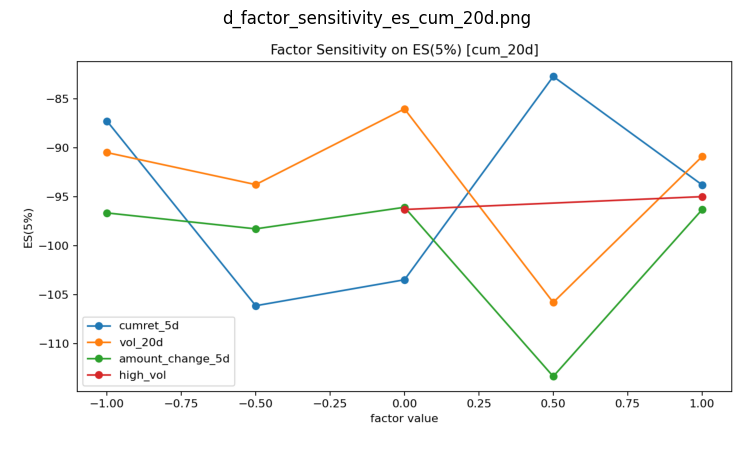

In [14]:
img_names = [
    'd_return_dist_last_day.png',
    'd_left_tail_compare_last_day.png',
    'd_es_by_condition_last_day.png',
    'd_return_dist_cum_20d.png',
    'd_left_tail_compare_cum_20d.png',
    'd_es_by_condition_cum_20d.png',
    'd_factor_sensitivity_es_last_day.png',
    'd_factor_sensitivity_es_cum_20d.png',
]

for name in img_names:
    p = FIG_DIR / name
    if not p.exists():
        print(f'[missing] {p}')
        continue
    img = plt.imread(p)
    plt.figure(figsize=(9.5, 4.6))
    plt.imshow(img)
    plt.title(name)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


## 6) What D-module has already delivered to the full project

The correct project-level conclusion is now clear.

D-module has already delivered:
- Reproducible risk tables.
- Real-versus-generated distribution diagnostics.
- Condition-level sensitivity analysis.
- A mechanism for rejecting overconfident claims when the model is still miscalibrated.

That last item is especially important. A good evaluation layer should not merely decorate the project. It should protect the project from claiming success too early.

So even though the current generator is not yet realistic enough, the D-module itself is already a meaningful and successful part of the engineering pipeline.
